In [ ]:
!pip install -U -q evaluate transformers datasets>=2.14.5 accelerate>=0.27 imbalanced-learn 2>/dev/null

In [ ]:
from google.colab import drive
import os

print(" Podłączam Dysk Google...")
drive.mount('/content/drive')

print(" Tworzenie folderów roboczych...")
os.makedirs('/content/auta', exist_ok=True)
os.makedirs('/content/cars', exist_ok=True)

print(" Rozpakowywanie dataset.zip...")
!unzip -q "/content/drive/MyDrive/auta.zip" -d "/content/auta"

print(" Rozpakowywanie kaggle_cars_collection.zip...")
!unzip -q "/content/drive/MyDrive/cars.zip" -d "/content/cars"

print(" Dane są na miejscu! Możesz przejść do przygotowania modelu ViT.")

 Podłączam Dysk Google...
Mounted at /content/drive
 Tworzenie folderów roboczych...
 Rozpakowywanie dataset.zip...
 Rozpakowywanie kaggle_cars_collection.zip...
 Dane są na miejscu! Możesz przejść do przygotowania modelu ViT.


In [ ]:
import pandas as pd
from glob import glob
from tqdm import tqdm
from imblearn.over_sampling import RandomOverSampler
from datasets import Dataset, Image, ClassLabel
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("🔍 Skanowanie folderów ze zdjęciami...")
katalogi_z_danymi = ["/content/auta", "/content/cars"]

file_names = []
labels = []
labels_correct_dict = {'MINI': 'Mini', 'INFINITI': 'Infiniti', 'FIAT': 'Fiat', 'smart': 'Smart'}

# Zbieranie ścieżek
for r in katalogi_z_danymi:
    znalezione_pliki = glob(f"{r}/*/*.jpg") + glob(f"{r}/*/*.png") + glob(f"{r}/*/*.jpeg") + glob(f"{r}/*.jpg") + glob(f"{r}/*.jpeg")
    for file in tqdm(znalezione_pliki, desc=f"Czytanie z {r}"):
        file_names.append(file)

        # Wyciąganie nazwy marki (Podobna logika co w naszym ResNecie)
        nazwa_pliku = file.split('/')[-1]
        nazwa_folderu = file.split('/')[-2]
        surowa_nazwa = nazwa_pliku.split('_')[0] if nazwa_pliku.count('_') > 5 else nazwa_folderu

        label = labels_correct_dict.get(surowa_nazwa, surowa_nazwa)
        labels.append(label)

print(f" Znaleziono {len(file_names)} zdjęć. Unikalnych marek: {len(set(labels))}")

df = pd.DataFrame({"image": file_names, "label": labels})
y = df[['label']]
df = df.drop(['label'], axis=1)

print("Wyrównywanie ilości zdjęć dla każdej z marek (RandomOverSampler)...")
ros = RandomOverSampler(random_state=2025)
df, y_resampled = ros.fit_resample(df, y)
df['label'] = y_resampled

print(f" Rozmiar bazy po wyrównaniu: {df.shape[0]} zdjęć (Wszystkie marki mają teraz równe szanse!)")

dataset = Dataset.from_pandas(df).cast_column("image", Image())
labels_list = sorted(list(set(labels)))

label2id = {label: i for i, label in enumerate(labels_list)}
id2label = {i: label for i, label in enumerate(labels_list)}
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)
dataset = dataset.cast_column('label', ClassLabels)

dataset = dataset.train_test_split(test_size=0.2, shuffle=True, stratify_by_column="label")
train_data = dataset['train']
test_data = dataset['test']
print(" Dane gotowe do treningu!")

🔍 Skanowanie folderów ze zdjęciami...


Czytanie z /content/cars: 100%|██████████| 64467/64467 [00:00<00:00, 535821.33it/s]


 Znaleziono 69064 zdjęć. Unikalnych marek: 55
Wyrównywanie ilości zdjęć dla każdej z marek (RandomOverSampler)...
 Rozmiar bazy po wyrównaniu: 284185 zdjęć (Wszystkie marki mają teraz równe szanse!)


Map:   0%|          | 0/284185 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/284185 [00:00<?, ? examples/s]

 Dane gotowe do treningu!


In [ ]:
import torch
import evaluate
import numpy as np
from transformers import (
    TrainingArguments, Trainer, ViTImageProcessor, ViTForImageClassification
)
from torchvision.transforms import (
    Compose, Normalize, RandomRotation, RandomAdjustSharpness, RandomHorizontalFlip, Resize, ToTensor
)

model_str = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_str)
size = processor.size["height"]

normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

_train_transforms = Compose([
    Resize((size, size)),
    RandomRotation(30),
    RandomAdjustSharpness(2),
    RandomHorizontalFlip(0.5),
    ToTensor(),
    normalize
])

_val_transforms = Compose([
    Resize((size, size)),
    ToTensor(),
    normalize
])

def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

train_data.set_transform(train_transforms)
test_data.set_transform(val_transforms)

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example['label'] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))
model.config.id2label = id2label
model.config.label2id = label2id

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    predicted_labels = predictions.argmax(axis=1)
    return {"accuracy": accuracy.compute(predictions=predicted_labels, references=label_ids)['accuracy']}

args = TrainingArguments(
    output_dir="model_vit_samochody",
    eval_strategy="epoch",
    save_strategy='epoch',
    learning_rate=5e-5, # Nieco wyższy LR niż w oryginale dla szybszej nauki
    per_device_train_batch_size=64, # Ustawione pod Twoją kartę A100!
    per_device_eval_batch_size=64,
    num_train_epochs=6,
    weight_decay=0.02,
    warmup_steps=50,
    remove_unused_columns=False,
    load_best_model_at_end=True,
    save_total_limit=1,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics
)

print("\nTRENING ")
trainer.train()

print("\n Trening zakończony! Zapisywanie modelu na dysku...")
trainer.save_model("najlepszy_model_vit_huggingface")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Trening zakończony! Zapisywanie modelu na dysku...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!cp -r /content/najlepszy_model_vit_huggingface /content/drive/MyDrive/moj_gotowy_model_vit

 Przeprowadzanie ostatecznego testu na zbiorze walidacyjnym (to chwilę potrwa)...



 RAPORT KLASYFIKACJI:
               precision    recall  f1-score   support

        Acura     0.9244    0.9351    0.9297      1033
   Alfa Romeo     0.9838    0.9981    0.9909      1034
 Aston Martin     0.9828    0.9961    0.9894      1034
         Audi     0.7087    0.7340    0.7211      1034
          BMW     0.6372    0.6267    0.6319      1034
      Bentley     0.9548    0.9826    0.9685      1033
      Bugatti     1.0000    1.0000    1.0000      1033
        Buick     0.9602    0.9574    0.9588      1033
     Cadillac     0.9393    0.9429    0.9411      1034
    Chevrolet     0.5653    0.5866    0.5758      1033
     Chrysler     0.9854    0.9806    0.9830      1033
      Citroen     0.9981    1.0000    0.9990      1034
       Daewoo     0.9971    1.0000    0.9986      1033
        Dodge     0.9246    0.9255    0.9250      1033
      Ferrari     0.9942    0.9932    0.9937      1034
         Fiat     0.9765    0.9652    0.9708      1033
         Ford     0.6069    0.6422    0.6

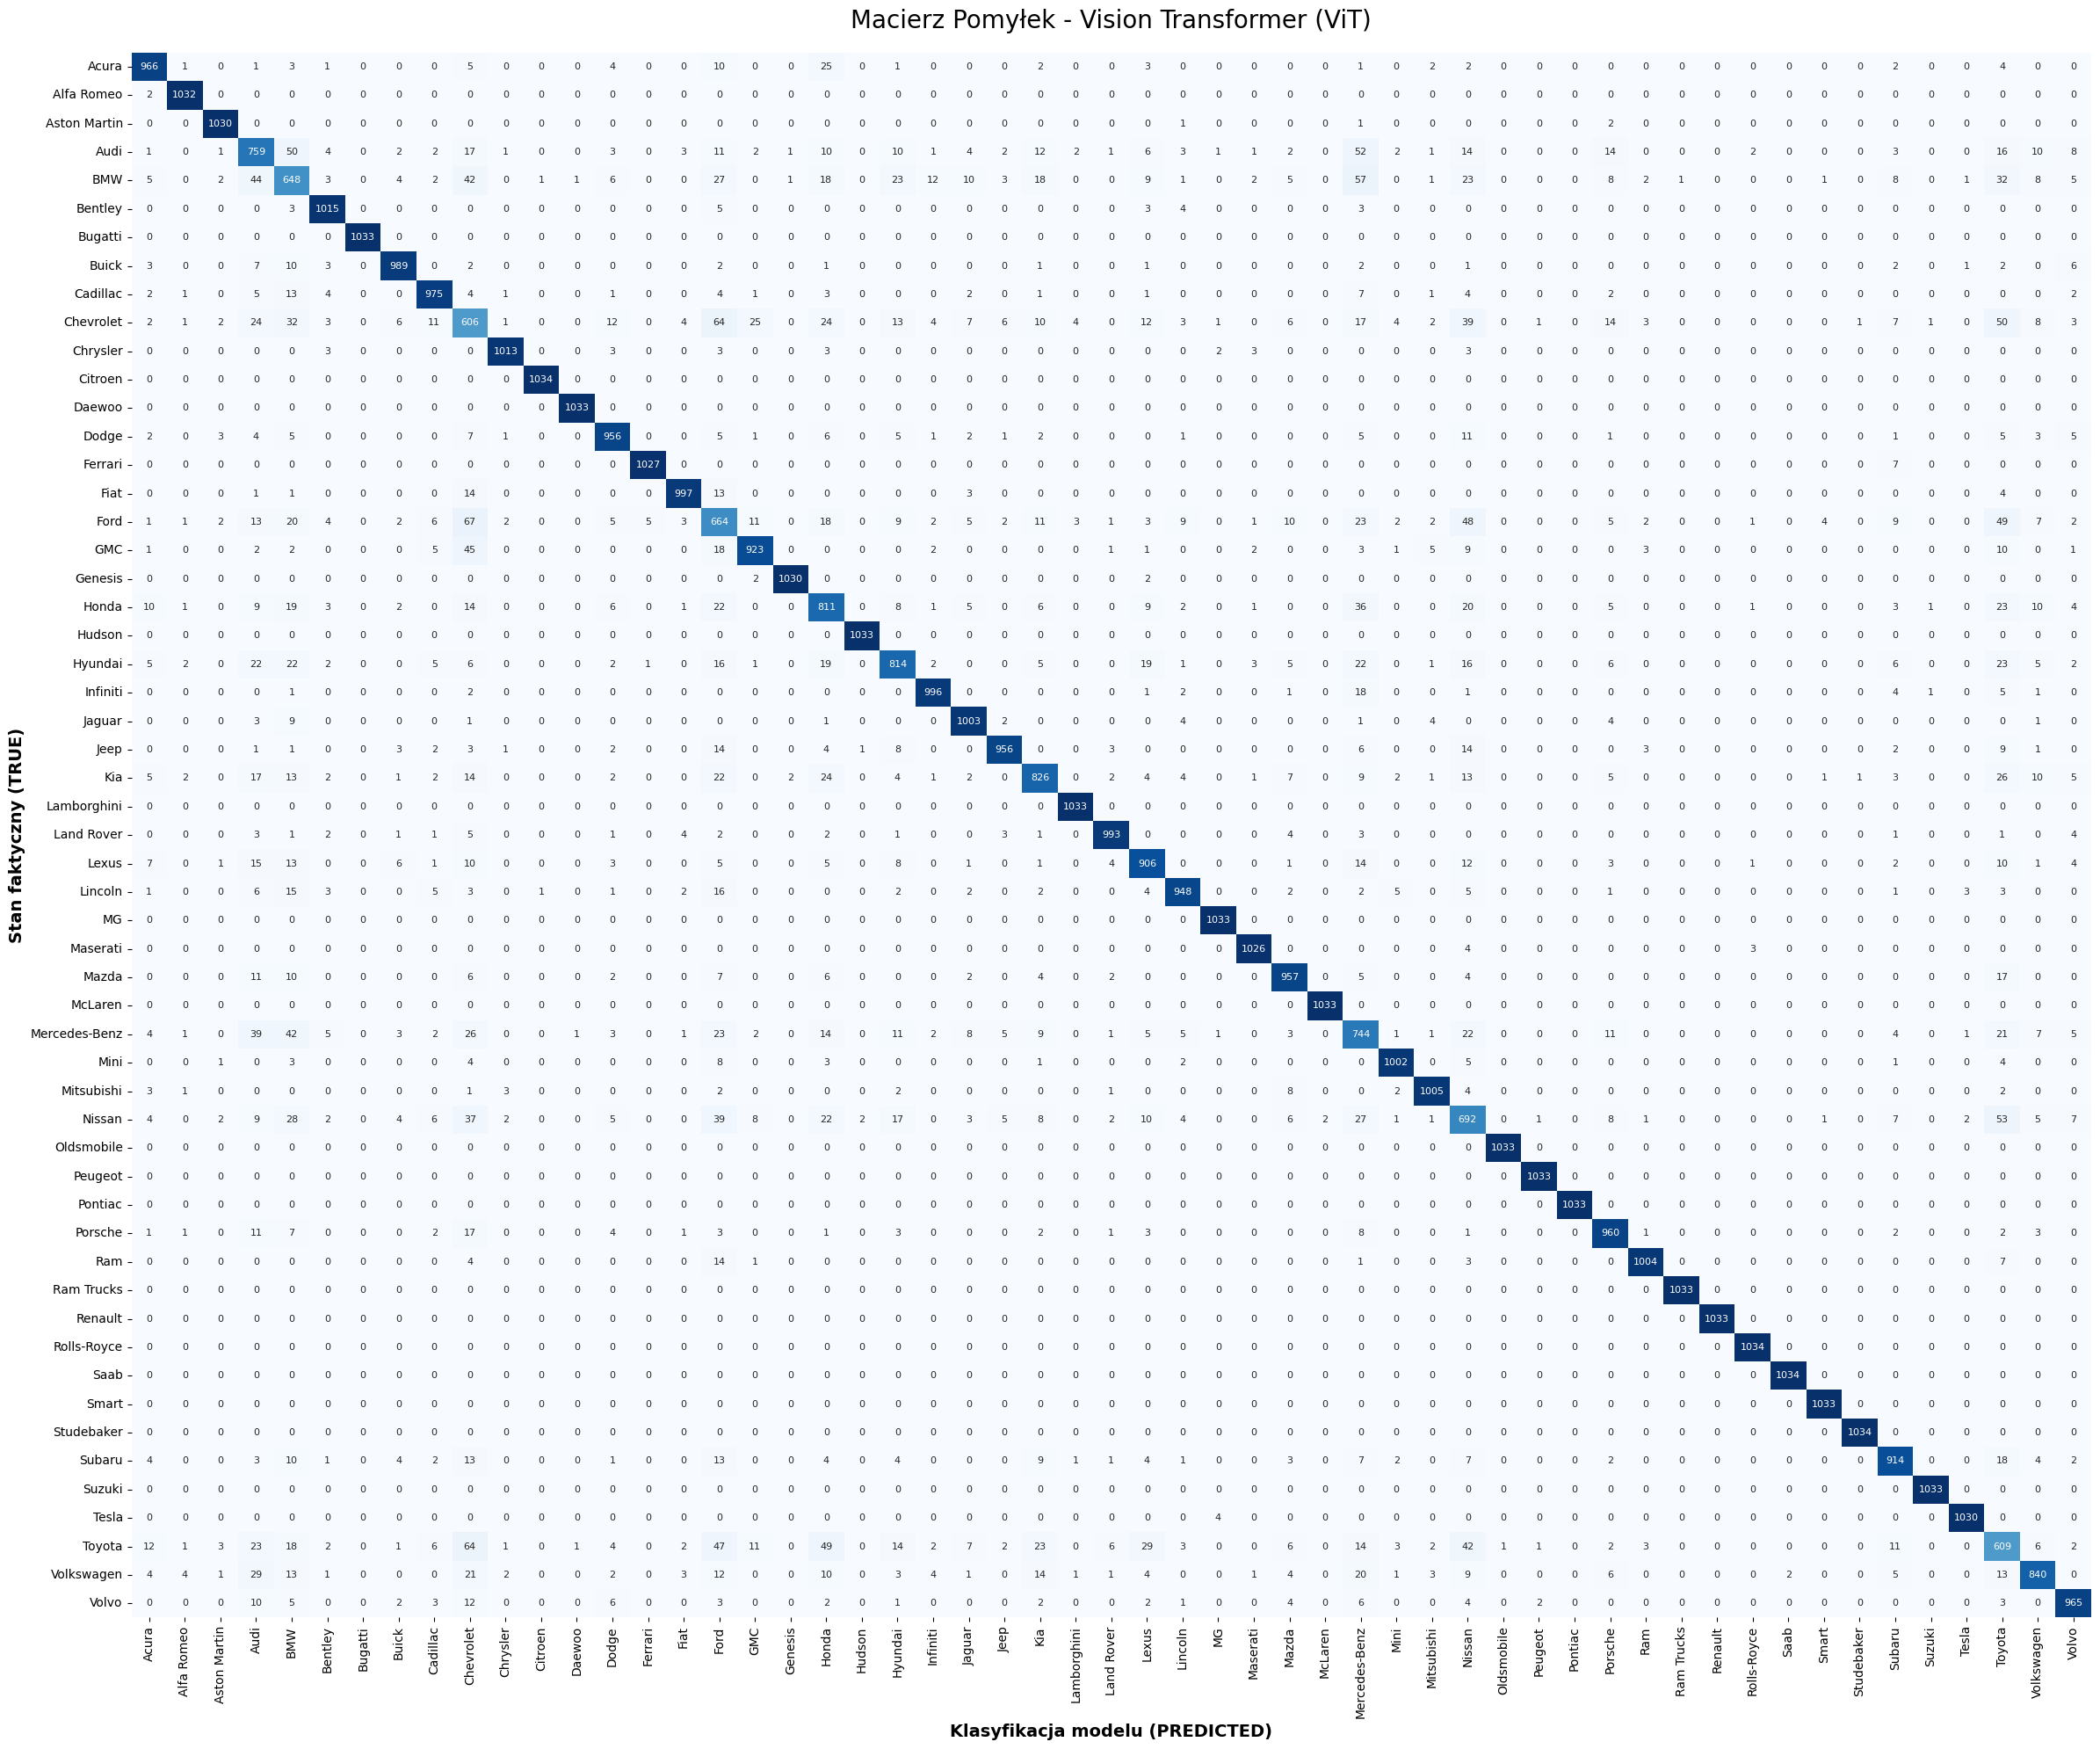

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print(" Przeprowadzanie ostatecznego testu na zbiorze walidacyjnym (to chwilę potrwa)...")
outputs = trainer.predict(test_data)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

print("\n RAPORT KLASYFIKACJI:")
print(classification_report(y_true, y_pred, target_names=labels_list, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list,
            cbar=False, annot_kws={"size": 8})

plt.title('Macierz Pomyłek - Vision Transformer (ViT)', fontsize=20, pad=20)
plt.ylabel('Stan faktyczny (TRUE)', fontsize=14, fontweight='bold')
plt.xlabel('Klasyfikacja modelu (PREDICTED)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("macierz_pomylek_vit.png", dpi=300)
print(" Wykres zapisany jako 'macierz_pomylek_vit.png'")
plt.show()

Oryginalne zdjęcie:


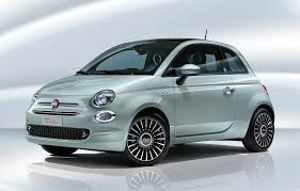


 WYNIKI ANALIZY VISION TRANSFORMERA:
1. Hyundai: 61.49%
2. Toyota: 11.69%
3. Mercedes-Benz: 8.67%


In [ ]:
import torch
import torchvision.transforms.functional as F
import numpy as np
from PIL import Image

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 0, 'constant')

sciezka_do_zdjecia = "/content/autko.jpg"
image = Image.open(sciezka_do_zdjecia).convert("RGB")

print("Oryginalne zdjęcie:")
display(image.resize((300, int(300 * image.height / image.width))))

image_padded = SquarePad()(image)

inputs = processor(images=image_padded, return_tensors="pt")

urzadzenie = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(urzadzenie)
inputs = {k: v.to(urzadzenie) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
top_prob, top_catid = torch.topk(probabilities, 3)

print("\n WYNIKI ANALIZY VISION TRANSFORMERA:")
for i in range(top_prob.size(0)):
    nazwa_klasy = model.config.id2label[top_catid[i].item()]
    pewnosc = top_prob[i].item() * 100
    print(f"{i+1}. {nazwa_klasy}: {pewnosc:.2f}%")